In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.integrate import odeint

import time
import pickle
import os

# Funciones principales

In [5]:

def Kerr_system(N, Delta, K, Epsilon):
    a = destroy(N) 
    """
Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        
    Regresa 
        Hamiltoniano: del sistema para un oscilador de Kerr 

     Hamiltoniano Kerr Oscillator de acuerdo al paper de Zhang2021:
         Detuning         (omega_d)
         No linealidad de Keer  (U)
         Squeezing              (G)
    """

    H = (
        - Delta*a.dag()*a               
        +  0.5*K* a.dag()*a.dag() *a*a       
        + 0.25*Epsilon* (a.dag()*a.dag() + a*a) 
        )
    
    return H
    
def Kerr_Diag(N, Delta, K, Epsilon, Jump_ops):
 
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa
        Eigenvalores del sistema.
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)
    L = liouvillian(H, Jump_ops)
    eigs = L.eigenenergies()

    return eigs

def Kerr_evo(N, Delta, K, Epsilon, t, init_rho, Jump_ops, Expected_ops):
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        t: array tipo linspace() de los valores del tiempo
        init_rho: Matriz de densidad inicial
        Jump_ops: array de los operadores de salto
        Expected_ops: array de los operadores que buscamos obtener su valor esperado
    
    Regresa 
        Estados evolucionados para cada paso de tiempo
        Evolución del valor de expectacion de los Expect_ops
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)


    evo = mesolve(H, init_rho, t, Jump_ops, e_ops = Expect_ops)

    return evo 

    



# Grafica No fotones vs epsilon : k$\langle n\rangle$ vs $\varepsilon$
Observamos la transición de fase para perdida de un fotón, sucede cuando $\varepsilon = \gamma $

In [21]:
# -----------------------Parametros-------------------------------
N = [20,40,60,80,100]              # dim Hilbert space
# Loss 
g = 1        
K_list = np.array(
    [1/15, 1/30, 1/60, 1/75]     # Interaction, Kerr NL
    )             
Delta = 0                         # Detuning 
epsi_list = np.linspace(0.01,2,100)    # Squeezing


# ------------------------------ CACHE ------------------------------
cache_folder = '1photon'
os.makedirs(cache_folder, exist_ok=True)
cache_file = os.path.join(cache_folder, 'NvsEpsi_data.npz')
# ------------------------------------------------------------------------------------------
if os.path.exists(cache_file):
    print("Cargando resultados desde caché...")
    data = np.load(cache_file, allow_pickle=True)
    # Acceso directo a los arrays
    n_ss_array = data['n_ss']  # Shape: (len(N), len(K_list), len(epsi_list))
    N_saved = data['N']
    K_saved = data['K_list']
    epsi_saved = data['epsi_list']
    print("----- O.o -----")
else:
    print("Calculando (esto puede tomar un momento)...") #------------------------------
    start_time = time.time()
    

    n_ss_all = np.zeros((len(N), len(K_list), len(epsi_list)))
    
    for i, d in enumerate(N):
        a = destroy(d)
        n = a.dag() * a
        salto = [
            np.sqrt(g) * a,
        ]
        
        for j, K in enumerate(K_list):
            print(f"d={d}, K={K:.4f}" + '\n')
            
            for k, e in enumerate(epsi_list):
                H = Kerr_system(d, Delta, K, e)
                rho_ss = steadystate(H, salto)    
                n_ss = expect(n, rho_ss)
                
                n_ss_all[i, j, k] = n_ss
                
                if k < 5:
                    print(
                        rf"eps={e:.3f}, "
                        f"<n>={n_ss:.4f}, "
                        f"Tr={rho_ss.tr():.8f}, "
                        f"Tr^2={(rho_ss*rho_ss).tr():.8f}, "
                        f"minEig={np.min(rho_ss.eigenenergies()):.3e}"
                    )
            print('\n')
    
    elapsed_time = time.time() - start_time
    print(f"Tiempo de cálculo: {elapsed_time:.2f} segundos")
    
    # Guardar en formato npz comprimido
    np.savez_compressed(
        cache_file,
        n_ss=n_ss_all,
        N=np.array(N),
        K_list=K_list,
        epsi_list=epsi_list,
        g=g,
        Delta=Delta
    )
    print(f"Datos guardados en {cache_file}")

Cargando resultados desde caché...
----- O.o -----


Haciendo MF obtenemos las siguientes ecuaciones i.e. $\langle \hat a \rangle = \alpha$ y $\langle \hat a^\dagger\hat a^2\rangle = \langle\hat a^\dagger \rangle\langle \hat a \rangle^2$:
$$
\frac{d\alpha}{dt} = \left(\Delta - K|\alpha|^2 +i \frac{\gamma}{2}\right)\alpha - \frac{\varepsilon}{2}\alpha^*
$$
El estado estacionario (ss) sucede cuando $\frac{d\alpha}{dt}=0$, que es lo mismo que decir que $\frac{d\rho(t)}{dt} = 0 = \mathcal L [\rho, L_k]$ i.e. el eigenvalor 0 del Lindbladiano. con $\alpha = \sqrt{n} e^{i\theta}$, donde n es el # de fotones, resolviendo para n 
$$
n_{ss} = \frac{1}{K} \left[\Delta \mp \frac{1}{2}\sqrt{|\varepsilon|^2 - \gamma^2}\right]
$$
En este caso particular y considerando $n\leq0$, llegando una expresion parecida a $\quad y = \frac{1}{2} \sqrt{x^2 - 1}$
$$
Kn_{ss} = \frac{1}{2} \sqrt{|\varepsilon|^2 - \gamma^2}
$$


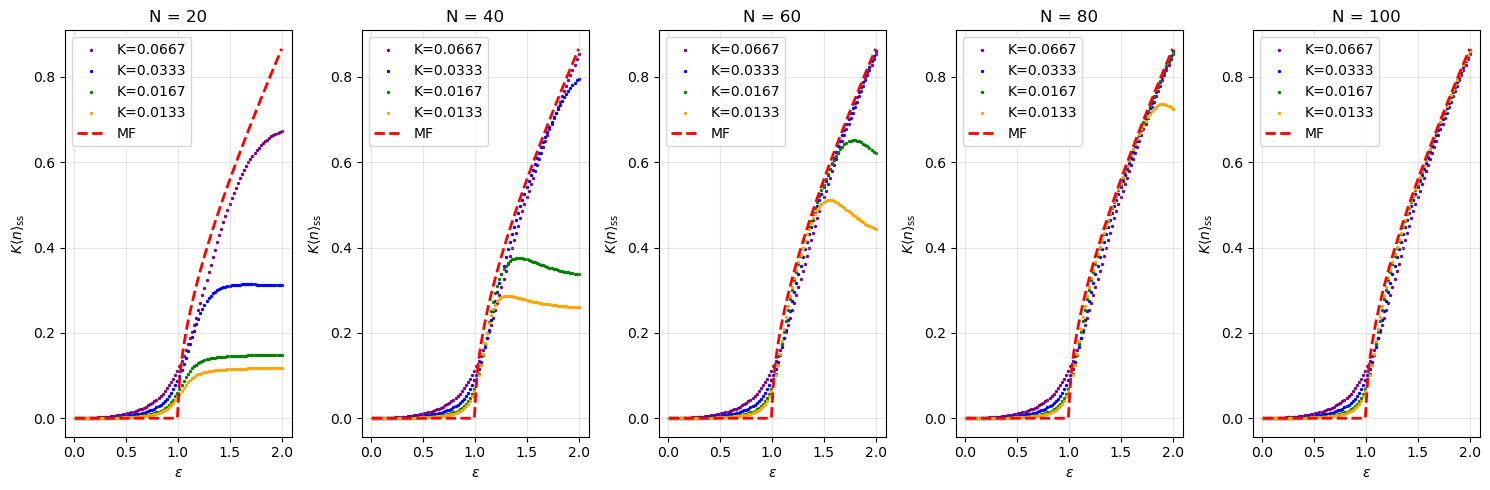

In [22]:
#---------- Mean Field -------------------------------------

r = np.clip(epsi_list**2 - g**2, a_min=0, a_max=None)
n_mf = Delta + 0.5 * np.sqrt(r)
#------------------------------------------------------------
"""
Para la grafica en el eje x seria mi epsi_list y el eje y es K*n_1values
"""
fig, axes = plt.subplots(1, len(N), figsize=(15, 5))
colors = ['purple', 'blue', 'green', 'orange']

for idx_d, (ax, d) in enumerate(zip(axes, N)):
    for i, K in enumerate(K_list):
        ax.scatter(epsi_list, K * n_ss_array[idx_d, i, :], 
                  c=colors[i % len(colors)], s=2, 
                  label=f"K={K:.4f}"
                  )
    
    ax.plot(epsi_list, n_mf, c='red', linewidth=2, linestyle='--', label='MF')
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$K\langle n\rangle_{\rm ss}$")
    ax.set_title(f"N = {d}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('1photon/n_vs_epsilon.pdf', dpi=300)
plt.show()



Cargando resultados desde caché...


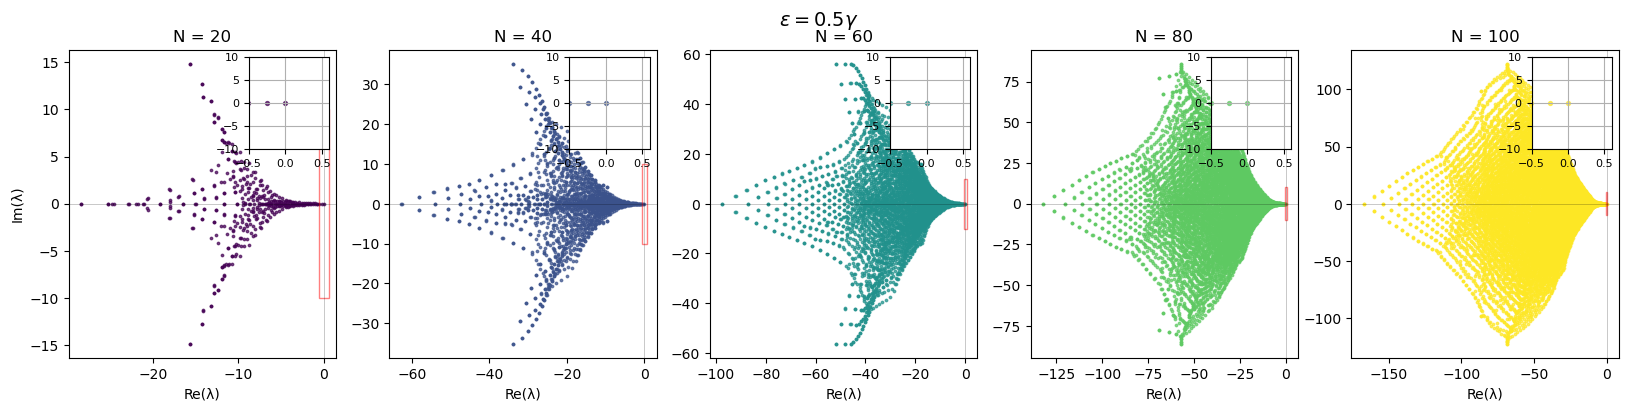

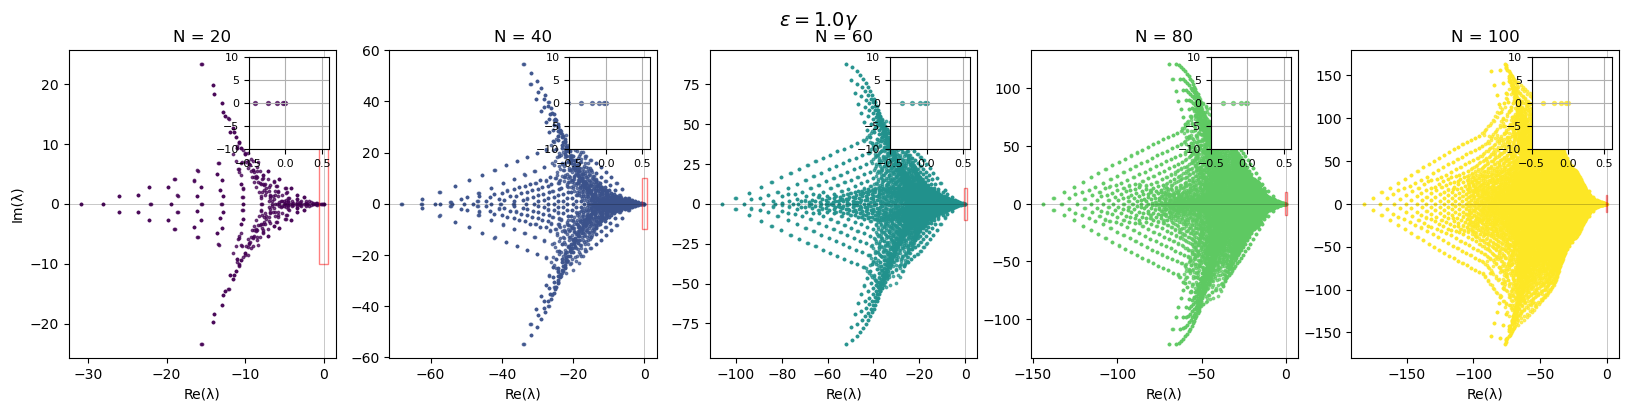

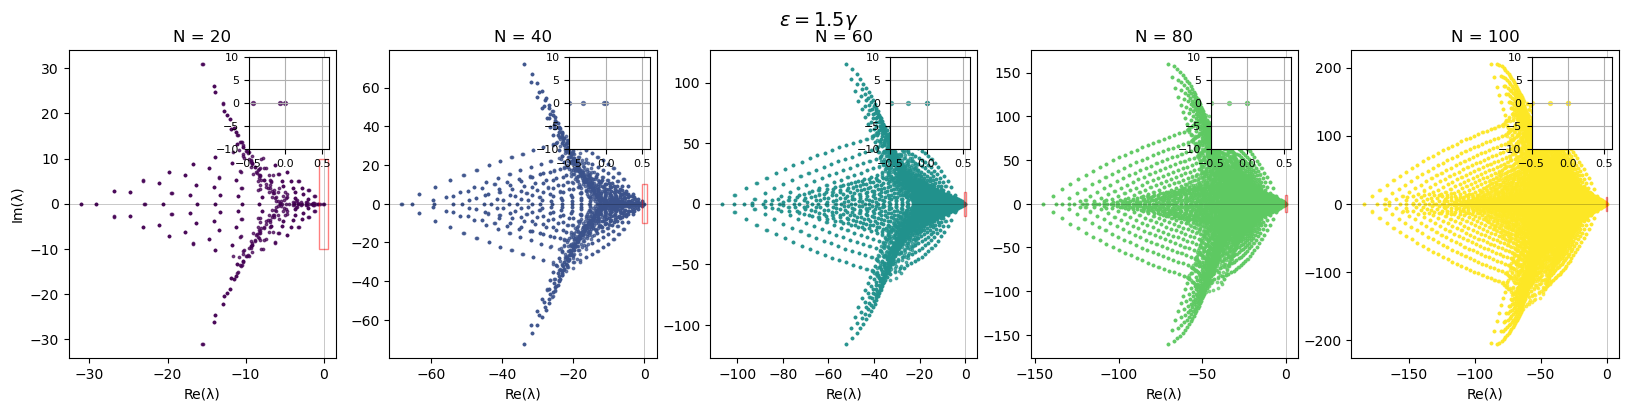

In [19]:


# Parámetros
N_values = [20, 40, 60, 80, 100]
g = 1.0
k = 1/60
Delta = 0
epsilon_values = [0.5*g, 1.0*g, 1.5*g]
epsilon_labels = [r'$\epsilon = 0.5\gamma$', r'$\epsilon = 1.0\gamma$', r'$\epsilon = 1.5\gamma$']

# Archivo de caché ------------------------------------------------------------------------------------------------------------------------------------------------

cache_folder = '1photon'  # Carpeta
# Archivo de caché con extensión .qu
cache_file = os.path.join(cache_folder, 'eigenvalues_cache.qu.qu')

# Intentar cargar desde caché
if os.path.exists(cache_file):
    print("Cargando resultados desde caché...")
    results_cache = qload('1photon/eigenvalues_cache.qu') 
else:
    results_cache = {}
    print("Calculando eigenvalores (esto puede tomar un momento)...")
    start_time = time.time()
    
    for eps in epsilon_values:
        for N in N_values:
            key = f"N{N}_eps{eps}"
            salto = [np.sqrt(g) * destroy(N)]
            eigs = Kerr_Diag(N, Delta, k, eps, salto)
            results_cache[key] = eigs
            print(f"  N={N}, eps={eps/g:.1f}g - listo")
    
    elapsed_time = time.time() - start_time
    print(f"Tiempo de cálculo: {elapsed_time:.2f} segundos")
    
    # Guardar en caché
    qsave(results_cache, cache_file)

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Crear figura - Una figura por cada valor de epsilon
for idx, (eps, label) in enumerate(zip(epsilon_values, epsilon_labels)):
    # Crear una figura con 5 subplots (una por cada N)
    fig, axes = plt.subplots(1, len(N_values), figsize=(20, 4))
    fig.suptitle(label, fontsize=14)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(N_values)))
    
    for i, N in enumerate(N_values):
        ax = axes[i]
        
        # Obtener eigenvalores del caché
        key = f"N{N}_eps{eps}"
        eigs = results_cache[key]
        
        X = np.real(eigs)
        Y = np.imag(eigs)
        
        ax.scatter(X, Y, s=3, c=[colors[i]], alpha=0.7, rasterized=True)
        
        ax.set_title(f'N = {N}', fontsize=12)
        ax.set_xlabel('Re(λ)', fontsize=10)
        if i == 0:
            ax.set_ylabel('Im(λ)', fontsize=10)
        
        ax.axhline(0, color='black', lw=0.5, alpha=0.3)
        ax.axvline(0, color='black', lw=0.5, alpha=0.3)
        
        # Opcional: ajustar límites si es necesario
        # ax.set_xlim([-20, 5])
        # ax.set_ylim([-50, 50])
        
        # Agregar zoom si quieres mantenerlo
        axins = inset_axes(ax, width="30%", height="30%", loc='upper right')
        mask = (X > -1.5) & (X < 1.5) & (Y > -15) & (Y < 15)
        if np.any(mask):
            axins.scatter(X[mask], Y[mask], s=8, c=[colors[i]], alpha=0.7)
        
        axins.set_xlim(-0.5, 0.6)
        axins.set_ylim(-10, 10)
        axins.grid(0.5)
        axins.tick_params(axis='both', labelsize=8)
        #axins.set_xticks([-2, -1.5, -1, -0.5, 0])
        axins.set_yticks([-10, -5, 0, 5, 10])
        
        # Indicador de zona de zoom
        from matplotlib.patches import Rectangle
        rect = Rectangle((-0.6, -10), 1.2, 20, 
                         linewidth=1, edgecolor='red', facecolor='none', alpha=0.5)
        ax.add_patch(rect)
    

    plt.savefig(f'1photon/eigsKerr_epsilon_{idx+1}.pdf', dpi=300)
    plt.show()

# Espacio fase 
Haciendo MFT obtenemos esta ecuacion del sistema
$$
\frac{d\alpha}{dt} = (i\Delta - iKn - \frac{\gamma}{2})\alpha - i \frac{\varepsilon}{2} \alpha^*
$$
Donde n = $|\alpha|^2$. La solución para el steady state $d\alpha / dt = 0$
$$
K n = \Delta \mp \frac{1}{2} \sqrt{\varepsilon^2 - \gamma^2}
$$
En el paper de Zhang2021 se centran cuando no hay detuning $\Delta = 0$ Considerando esto y sustituyendo $\alpha = \sqrt{n}e^{i\theta}$ en (1) en el ss
$$
e^{i2\theta} =  -\frac{1}{\varepsilon^*} \left(\sqrt{\varepsilon^2 - \gamma^2} +  i\gamma \right)
$$
Podemos observar el espacio fase, conociendo como evoluciona $\alpha$ y  $\alpha^*$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


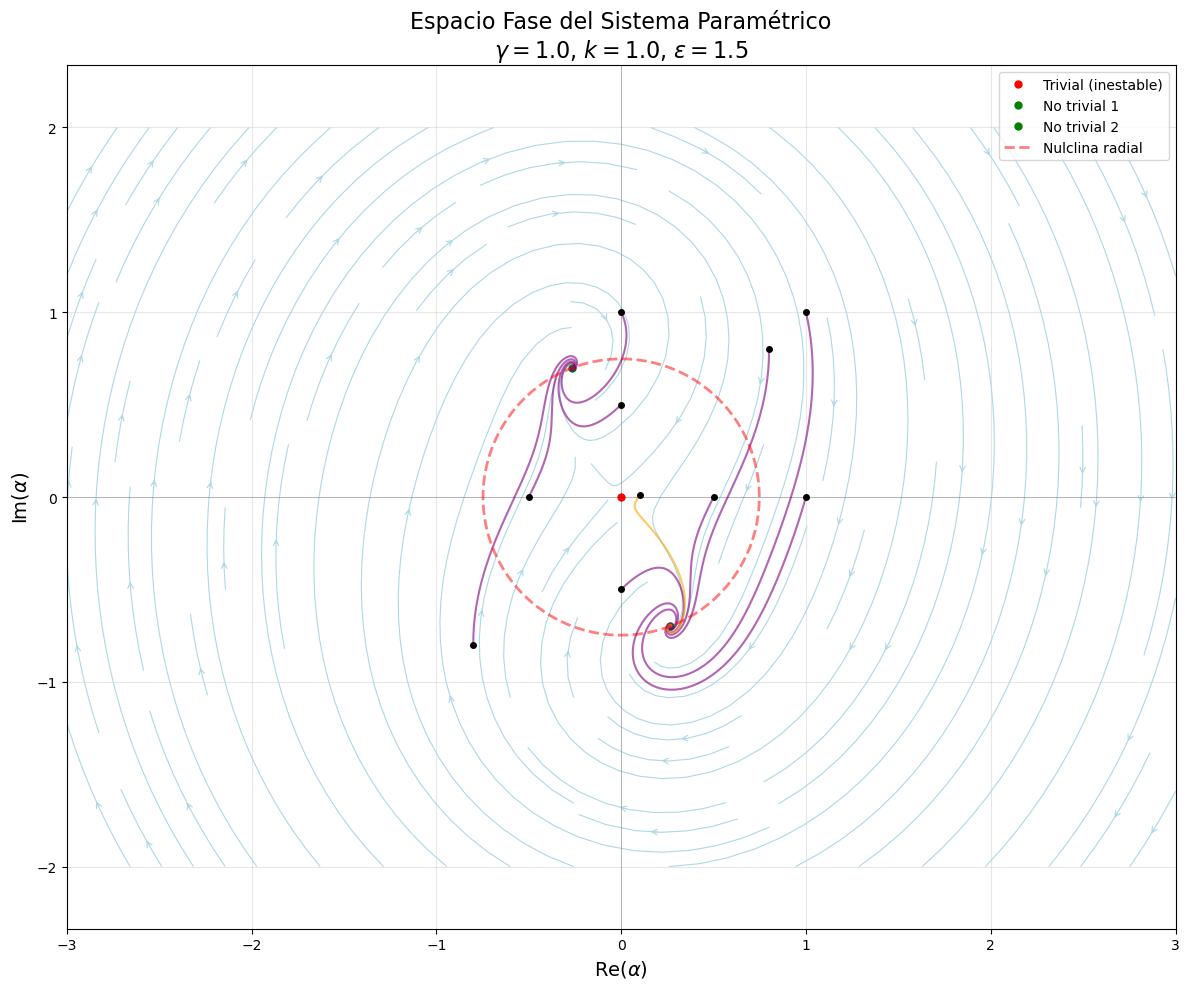

PUNTOS FIJOS DEL SISTEMA
Trivial (inestable):
  α = 0.0000+0.0000j
  |α| = 0.0000
  θ = 0.0000 rad

No trivial 1:
  α = 0.2668-0.6985j
  |α| = 0.7477
  θ = -1.2059 rad

No trivial 2:
  α = -0.2668+0.6985j
  |α| = 0.7477
  θ = 1.9357 rad


ESTABILIDAD APROXIMADA:
  • Punto trivial (α=0): Inestable (silla)
  • Puntos no triviales: Estables (atractores)


In [16]:

# ============================================
# PARAMETROS DEL SISTEMA 
# ============================================
gamma = 1.0      # Tasa de disipación
k = 1.0          # No linealidad de Kerr (U)
epsilon = 1.5   # Amplitud de driving paramétrico (G)
delta = 0
# ============================================
# SISTEMA DE ECUACIONES
# ============================================
def MFsystem(y, t, gamma, k, epsilon):

    alpha = y[0] + 1j*y[1]
    
    dalpha_dt = (1j * delta -1j * k * np.abs(alpha)**2 - gamma/2) * alpha - 1j * epsilon/2 * np.conj(alpha)
    
    return [np.real(dalpha_dt), np.imag(dalpha_dt)]

# ============================================
# PUNTOS FIJOS (ESTADO ESTACIONARIO)
# ============================================
def puntos_fijos(gamma, k, epsilon):
    """
    Calcula los puntos fijos del sistema.
    """
    puntos = []
    
    # Punto fijo trivial n = 0
    puntos.append((0, 0, 'Trivial (inestable)'))
    
    # Puntos fijos no triviales (eps > gamma)
    if epsilon > gamma:
        r2 = np.sqrt(epsilon**2 - gamma**2) / (2 * k)
        r = np.sqrt(r2)
        
        # La fase se determina por la ecuación de fase
        # e^{2iθ} = -(sqrt(epsilon^2 - gamma^2) + i*gamma)/epsilon
        # (eps > 0 )
        numerador = -(np.sqrt(epsilon**2 - gamma**2) + 1j*gamma)
        fase = numerador / epsilon
        
        # Extraer fase
        theta = 0.5 * np.angle(fase)
        
        # Dos soluciones con fase θ y θ + π (simetría Z2)
        alpha1 = r * np.exp(1j * theta)
        alpha2 = r * np.exp(1j * (theta + np.pi))
        
        puntos.append((np.real(alpha1), np.imag(alpha1), 'No trivial 1'))
        puntos.append((np.real(alpha2), np.imag(alpha2), 'No trivial 2'))
    
    return puntos

# ============================================
# FUNCIÓN PARA GENERAR EL CAMPO VECTORIAL
# ============================================
def campo_vectorial(X, Y, gamma, k, epsilon):
    """
    Calcula el campo vectorial en el plano (X, Y).
    """
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            alpha = X[i,j] + 1j*Y[i,j]
            dalpha_dt = (1j * delta -1j * k * np.abs(alpha)**2 - gamma/2) * alpha - 1j * epsilon/2 * np.conj(alpha)
            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)
    
    return U, V

# ============================================
# FUNCIÓN PARA TRAZAR TRAYECTORIAS
# ============================================
def trayectoria(alpha0, t_max=20, n_points=1000):
    """
    Calcula la trayectoria desde una condición inicial alpha0.
    """
    t = np.linspace(0, t_max, n_points)
    X_0 = np.real(alpha0)
    Y_0 = np.imag(alpha0)
    sol = odeint(MFsystem, [X_0,Y_0], t, args=(gamma, k, epsilon))
    return sol[:, 0] + 1j*sol[:, 1], t

# ============================================
# NULCLINAS
# ============================================
# Las nulclinas son curvas donde dα/dt = 0
# Para este sistema, la nulclina satisface:
# (-ik|α|^2 - γ/2)α - iε/2 α* = 0

def nulclina_real(gamma, k, epsilon):
    """Calcula la nulclina para la parte real."""
    # La ecuación es compleja, resolvemos numéricamente
    # dα/dt = 0 => α = 0 o |α|^2 = sqrt(ε^2 - γ^2)/(2k)
    if epsilon > gamma:
        r = np.sqrt(np.sqrt(epsilon**2 - gamma**2) / (2*k))
        # La nulclina es un círculo de radio r (para la parte radial)
        # Más precisamente, es la curva donde la parte radial es cero
        theta = np.linspace(0, 2*np.pi, 100)
        x_circ = r * np.cos(theta)
        y_circ = r * np.sin(theta)
        return x_circ, y_circ
    else:
        return np.array([]), np.array([])


# ============================================
# CONFIGURACIÓN DE LA GRÁFICA
# ============================================
plt.figure(figsize=(12, 10))

# Rango del espacio fase
lim = 2.0
x = np.linspace(-lim, lim, 30)
y = np.linspace(-lim, lim, 30)
X, Y = np.meshgrid(x, y)

# Calcular campo vectorial
U, V = campo_vectorial(X, Y, gamma, k, epsilon)

# Graficar campo vectorial (flujo)
plt.streamplot(X, Y, U, V, color='lightblue', linewidth=0.8, density=1.2, 
               arrowstyle='->', arrowsize=1.0)

# Calcular y graficar puntos fijos
puntos = puntos_fijos(gamma, k, epsilon)
for xp, yp, label in puntos:
    if 'Trivial' in label:
        plt.plot(xp, yp, 'ro', markersize=5, label=label)
    else:
        plt.plot(xp, yp, 'go', markersize=5, label=label)

# Graficar algunas trayectorias representativas
ini_con = [
    0.5 + 0.0j,
    0.0 + 0.5j,
    -0.5 + 0.0j,
    0.0 - 0.5j,
    0.8 + 0.8j,
    -0.8 - 0.8j,
    1.0 + 0.0j,
    0.0 + 1.0j,
    1.0 + 1.0j,
    0.1 + 0.01j
]

for alpha0 in ini_con:
    tray, t = trayectoria(alpha0, t_max=30, n_points=2000)
    
    # Color según la condición inicial
    if np.abs(alpha0) < 0.3:
        color = 'orange'
    else:
        color = 'purple'
    
    plt.plot(np.real(tray), np.imag(tray), color=color, alpha=0.6, linewidth=1.5)
    
    # Marcar punto inicial
    plt.plot(np.real(alpha0), np.imag(alpha0), 'k.', markersize=8)

plt.axhline(0, color='black', linewidth=0.5, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.3)
plt.xlabel('Re($\\alpha$)', fontsize=14)
plt.ylabel('Im($\\alpha$)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.title(f'Espacio Fase del Sistema Paramétrico\n'
          f'$\\gamma = {gamma}$, $k = {k}$, $\\epsilon = {epsilon}$', 
          fontsize=16)
plt.legend(loc='best')
plt.axis('equal')
#plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.tight_layout()

# Graficar nulclinas (círculo donde la dinámica radial se anula)
if epsilon > gamma:
    x_circ, y_circ = nulclina_real(gamma, k, epsilon)
    plt.plot(x_circ, y_circ, 'r--', linewidth=2, label='Nulclina radial', alpha =0.5)
    plt.xlabel('Re($\\alpha$)', fontsize=14)
    plt.ylabel('Im($\\alpha$)', fontsize=14)
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.savefig('PhaseSpace1ph.pdf')
    plt.show()
else:
    plt.show()
# ============================================
# INFORMACIÓN DE LOS PUNTOS FIJOS
# ============================================
print("="*50)
print("PUNTOS FIJOS DEL SISTEMA")
print("="*50)
for xp, yp, label in puntos:
    alpha = xp + 1j*yp
    r = np.abs(alpha)
    theta = np.angle(alpha)
    print(f"{label}:")
    print(f"  α = {alpha:.4f}")
    print(f"  |α| = {r:.4f}")
    print(f"  θ = {theta:.4f} rad")
    print()

# Verificar estabilidad (aproximada)
print("\nESTABILIDAD APROXIMADA:")
print("  • Punto trivial (α=0):", "Inestable (silla)" if epsilon > gamma else "Estable")
print("  • Puntos no triviales:", "Estables (atractores)" if epsilon > gamma else "No existen")




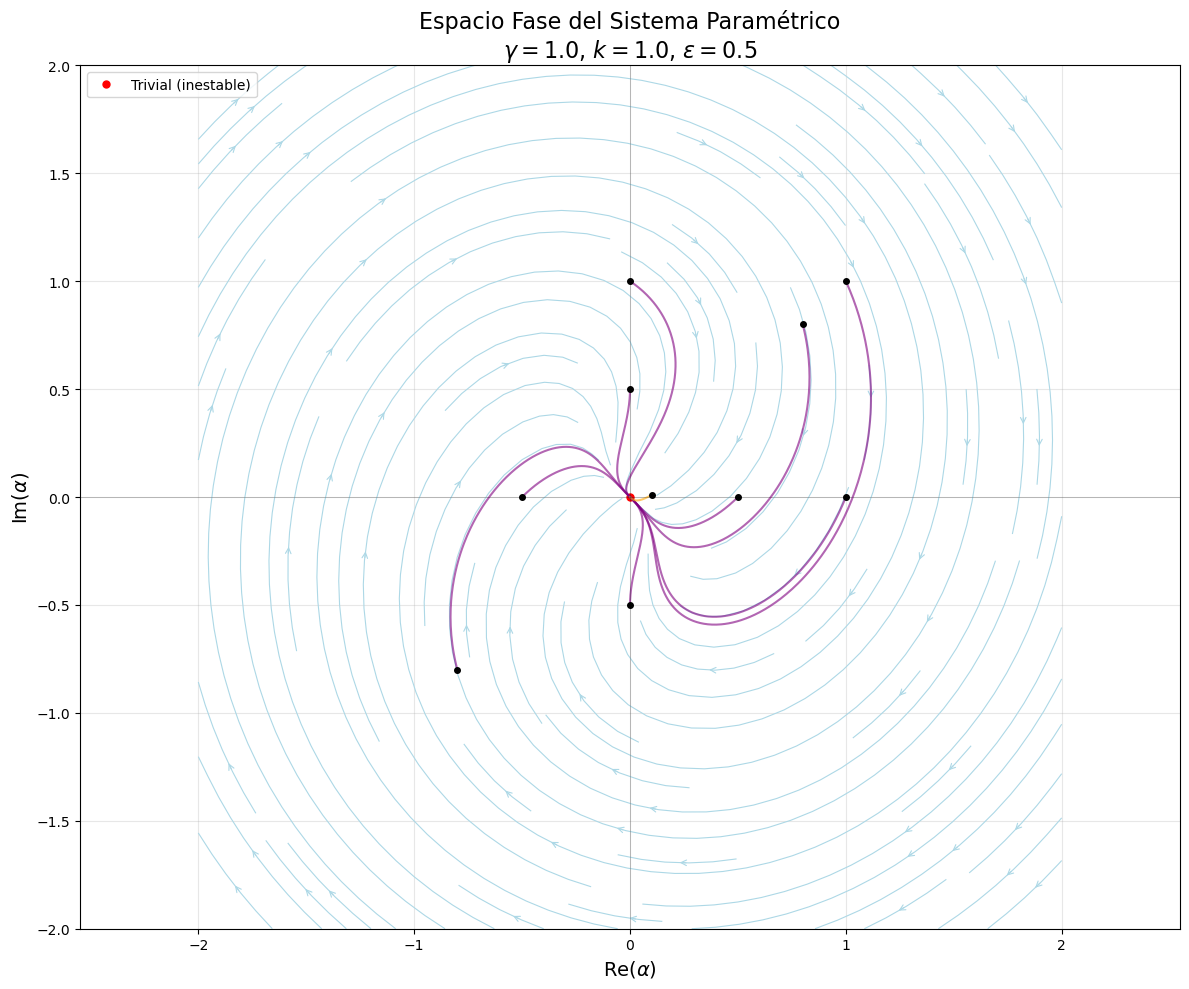

PUNTOS FIJOS DEL SISTEMA
Trivial (inestable):
  α = 0.0000+0.0000j
  |α| = 0.0000
  θ = 0.0000 rad


ESTABILIDAD APROXIMADA:
  • Punto trivial (α=0): Estable
  • Puntos no triviales: No existen


In [17]:

# ============================================
# PARAMETROS DEL SISTEMA 
# ============================================
gamma = 1.0      # Tasa de disipación
k = 1.0          # No linealidad de Kerr (U)
epsilon = 0.5   # Amplitud de driving paramétrico (G)
delta = 0
# ============================================
# SISTEMA DE ECUACIONES
# ============================================
def MFsystem(y, t, gamma, k, epsilon):

    alpha = y[0] + 1j*y[1]
    
    dalpha_dt = (1j * delta -1j * k * np.abs(alpha)**2 - gamma/2) * alpha - 1j * epsilon/2 * np.conj(alpha)
    
    return [np.real(dalpha_dt), np.imag(dalpha_dt)]

# ============================================
# PUNTOS FIJOS (ESTADO ESTACIONARIO)
# ============================================
def puntos_fijos(gamma, k, epsilon):
    """
    Calcula los puntos fijos del sistema.
    """
    puntos = []
    
    # Punto fijo trivial n = 0
    puntos.append((0, 0, 'Trivial (inestable)'))
    
    # Puntos fijos no triviales (eps > gamma)
    if epsilon > gamma:
        r2 = np.sqrt(epsilon**2 - gamma**2) / (2 * k)
        r = np.sqrt(r2)
        
        # La fase se determina por la ecuación de fase
        # e^{2iθ} = -(sqrt(epsilon^2 - gamma^2) + i*gamma)/epsilon
        # (eps > 0 )
        numerador = -(np.sqrt(epsilon**2 - gamma**2) + 1j*gamma)
        fase = numerador / epsilon
        
        # Extraer fase
        theta = 0.5 * np.angle(fase)
        
        # Dos soluciones con fase θ y θ + π (simetría Z2)
        alpha1 = r * np.exp(1j * theta)
        alpha2 = r * np.exp(1j * (theta + np.pi))
        
        puntos.append((np.real(alpha1), np.imag(alpha1), 'No trivial 1'))
        puntos.append((np.real(alpha2), np.imag(alpha2), 'No trivial 2'))
    
    return puntos

# ============================================
# FUNCIÓN PARA GENERAR EL CAMPO VECTORIAL
# ============================================
def campo_vectorial(X, Y, gamma, k, epsilon):
    """
    Calcula el campo vectorial en el plano (X, Y).
    """
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            alpha = X[i,j] + 1j*Y[i,j]
            dalpha_dt = (1j * delta -1j * k * np.abs(alpha)**2 - gamma/2) * alpha - 1j * epsilon/2 * np.conj(alpha)
            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)
    
    return U, V

# ============================================
# FUNCIÓN PARA TRAZAR TRAYECTORIAS
# ============================================
def trayectoria(alpha0, t_max=20, n_points=1000):
    """
    Calcula la trayectoria desde una condición inicial alpha0.
    """
    t = np.linspace(0, t_max, n_points)
    X_0 = np.real(alpha0)
    Y_0 = np.imag(alpha0)
    sol = odeint(MFsystem, [X_0,Y_0], t, args=(gamma, k, epsilon))
    return sol[:, 0] + 1j*sol[:, 1], t

# ============================================
# NULCLINAS
# ============================================
# Las nulclinas son curvas donde dα/dt = 0
# Para este sistema, la nulclina satisface:
# (-ik|α|^2 - γ/2)α - iε/2 α* = 0

def nulclina_real(gamma, k, epsilon):
    """Calcula la nulclina para la parte real."""
    # La ecuación es compleja, resolvemos numéricamente
    # dα/dt = 0 => α = 0 o |α|^2 = sqrt(ε^2 - γ^2)/(2k)
    if epsilon > gamma:
        r = np.sqrt(np.sqrt(epsilon**2 - gamma**2) / (2*k))
        # La nulclina es un círculo de radio r (para la parte radial)
        # Más precisamente, es la curva donde la parte radial es cero
        theta = np.linspace(0, 2*np.pi, 100)
        x_circ = r * np.cos(theta)
        y_circ = r * np.sin(theta)
        return x_circ, y_circ
    else:
        return np.array([]), np.array([])


# ============================================
# CONFIGURACIÓN DE LA GRÁFICA
# ============================================
plt.figure(figsize=(12, 10))

# Rango del espacio fase
lim = 2.0
x = np.linspace(-lim, lim, 30)
y = np.linspace(-lim, lim, 30)
X, Y = np.meshgrid(x, y)

# Calcular campo vectorial
U, V = campo_vectorial(X, Y, gamma, k, epsilon)

# Graficar campo vectorial (flujo)
plt.streamplot(X, Y, U, V, color='lightblue', linewidth=0.8, density=1.2, 
               arrowstyle='->', arrowsize=1.0)

# Calcular y graficar puntos fijos
puntos = puntos_fijos(gamma, k, epsilon)
for xp, yp, label in puntos:
    if 'Trivial' in label:
        plt.plot(xp, yp, 'ro', markersize=5, label=label)
    else:
        plt.plot(xp, yp, 'go', markersize=5, label=label)

# Graficar algunas trayectorias representativas
ini_con = [
    0.5 + 0.0j,
    0.0 + 0.5j,
    -0.5 + 0.0j,
    0.0 - 0.5j,
    0.8 + 0.8j,
    -0.8 - 0.8j,
    1.0 + 0.0j,
    0.0 + 1.0j,
    1.0 + 1.0j,
    0.1 + 0.01j
]

for alpha0 in ini_con:
    tray, t = trayectoria(alpha0, t_max=30, n_points=2000)
    
    # Color según la condición inicial
    if np.abs(alpha0) < 0.3:
        color = 'orange'
    else:
        color = 'purple'
    
    plt.plot(np.real(tray), np.imag(tray), color=color, alpha=0.6, linewidth=1.5)
    
    # Marcar punto inicial
    plt.plot(np.real(alpha0), np.imag(alpha0), 'k.', markersize=8)

plt.axhline(0, color='black', linewidth=0.5, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.3)
plt.xlabel('Re($\\alpha$)', fontsize=14)
plt.ylabel('Im($\\alpha$)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.title(f'Espacio Fase del Sistema Paramétrico\n'
          f'$\\gamma = {gamma}$, $k = {k}$, $\\epsilon = {epsilon}$', 
          fontsize=16)
plt.legend(loc='best')
plt.axis('equal')
#plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.tight_layout()

# Graficar nulclinas (círculo donde la dinámica radial se anula)
if epsilon > gamma:
    x_circ, y_circ = nulclina_real(gamma, k, epsilon)
    plt.plot(x_circ, y_circ, 'r--', linewidth=2, label='Nulclina radial', alpha =0.5)
    plt.xlabel('Re($\\alpha$)', fontsize=14)
    plt.ylabel('Im($\\alpha$)', fontsize=14)
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.savefig('PhaseSpace1ph.pdf')
    plt.show()
else:
    plt.show()
# ============================================
# INFORMACIÓN DE LOS PUNTOS FIJOS
# ============================================
print("="*50)
print("PUNTOS FIJOS DEL SISTEMA")
print("="*50)
for xp, yp, label in puntos:
    alpha = xp + 1j*yp
    r = np.abs(alpha)
    theta = np.angle(alpha)
    print(f"{label}:")
    print(f"  α = {alpha:.4f}")
    print(f"  |α| = {r:.4f}")
    print(f"  θ = {theta:.4f} rad")
    print()

# Verificar estabilidad (aproximada)
print("\nESTABILIDAD APROXIMADA:")
print("  • Punto trivial (α=0):", "Inestable (silla)" if epsilon > gamma else "Estable")
print("  • Puntos no triviales:", "Estables (atractores)" if epsilon > gamma else "No existen")

